# Mid-project EDA — bank loan defaults

Що в нас є: Kaggle InClass competition про прогноз default на loan/credit line протягом 2 років. Метрика — ROC AUC, тобто треба передбачати ймовірність, не клас.

Перш ніж переходити до моделей — треба зрозуміти що в датасеті, чого там бракує і де можуть бути сюрпризи. Спочатку — overview, далі по полях, потім зведу correlation + bivariate з target.

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='notebook')

import kagglehub
DATA = kagglehub.competition_download('mid-project-danit-ds-5-ds-5')
train = pd.read_csv(f'{DATA}/train.csv')
test  = pd.read_csv(f'{DATA}/test.csv')
print(train.shape, test.shape)
train.head()

(72161, 12) (48108, 11)


,Id,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,number_of_previous_late_payments_up_to_59_days,number_of_previous_late_payments_up_to_89_days,number_of_previous_late_payments_90_days_or_more,defaulted_on_loan
0,1,66.0,NaN,4000.0,NaN,1.0,0.569108,0.05488766900000001,0.0,0.0,0.0,0
1,2,61.0,2.0,4000.0,6.0,1.0,0.297176,0.10194991099999999,0.0,0.0,0.0,0
2,3,31.0,2.0,3040.0,8.0,0.0,0.160145,1.22713507,4.0,0.0,0.0,1
3,4,54.0,4.0,10218.0,5.0,0.0,0.067913,0.08327777900000001,0.0,0.0,0.0,0
4,5,29.0,0.0,4468.0,6.0,0.0,0.328261,0.317445504,0.0,0.0,0.0,0


72k train / 48k test — нормально. Подивимось на типи. Буває що pandas одразу визначає тип не так як хочеться.

In [2]:
train.dtypes

Id                                                    int64
age                                                 float64
number_dependent_family_members                     float64
monthly_income                                      float64
number_of_credit_lines                              float64
real_estate_loans                                   float64
ratio_debt_payment_to_income                        float64
credit_line_utilization                                 str
number_of_previous_late_payments_up_to_59_days      float64
number_of_previous_late_payments_up_to_89_days      float64
number_of_previous_late_payments_90_days_or_more    float64
defaulted_on_loan                                     int64
dtype: object

Окей, `credit_line_utilization` — **object**, тобто рядок. Інші — float64. Це вже сигнал що щось не так, бо utilization має бути дробовим числом (balance / credit limit). Подивимось що там.

In [3]:
util = train['credit_line_utilization'].dropna()
# дивлюсь на ті значення, які не парсяться як float
def looks_numeric(s):
    try:
        float(s)
        return True
    except (TypeError, ValueError):
        return False
non_num = util[~util.map(looks_numeric)]
print(f'non-numeric values: {len(non_num)} of {len(util)}')
print('top samples:')
print(non_num.value_counts().head(10))

non-numeric values: 7929 of 65815
top samples:
credit_line_utilization
0,0                     571
0,9999998999999999      506
0,007984032               3
0,803196803               2
0,616766467               2
1,0                       2
0,036474087999999995      2
0,9838032390000001        2
0,317365269               2
0,020979021               2
Name: count, dtype: int64


Так — у частині значень кома як десятковий розділювач. Це буває коли датасет збирали в локалях де `,` = десятковий знак (DE, UA, RU). Просто replace → float.

In [4]:
def parse_util(x):
    if pd.isna(x): return np.nan
    return float(str(x).replace(',', '.'))

train['credit_line_utilization'] = train['credit_line_utilization'].map(parse_util)
test['credit_line_utilization']  = test['credit_line_utilization'].map(parse_util)
print('train util describe:')
train['credit_line_utilization'].describe()

train util describe:


count    65815.000000
mean         5.225040
std        212.152963
min          0.000000
25%          0.035123
50%          0.176500
75%          0.578536
max      29110.000000
Name: credit_line_utilization, dtype: float64

Max ~50000 — підозріло, треба окремо оглянути нижче. Поки фіксую що тип вже numeric.

## Target

Перше що цікавить — наскільки збалансовані класи.

defaulted_on_loan
0    67148
1     5013
Name: count, dtype: int64

default rate: 0.0695


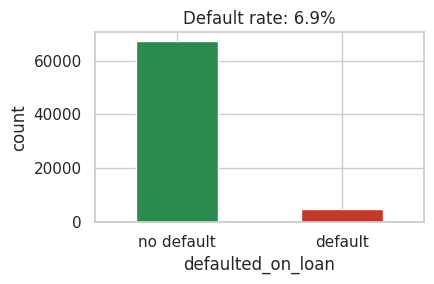

In [5]:
target = train['defaulted_on_loan']
print(target.value_counts(normalize=False))
print(f'\ndefault rate: {target.mean():.4f}')

fig, ax = plt.subplots(figsize=(4.5, 3))
target.value_counts().plot.bar(ax=ax, color=['#2c8a4d', '#c0392b'])
ax.set_xticklabels(['no default', 'default'], rotation=0)
ax.set_ylabel('count')
ax.set_title(f'Default rate: {target.mean()*100:.1f}%')
plt.tight_layout(); plt.show()

~7% defaults. Очікувано — реальні дефолти рідкі. Що з цього випливає:
- accuracy будe brutally optimistic (constant 0 = 93%)
- AUC коректна метрика тут, добре що Kaggle обрав її
- для тренування — class weights / scale_pos_weight в boosting

## Missing values

In [6]:
miss = train.isna().sum().to_frame('count')
miss['pct'] = (miss['count'] / len(train) * 100).round(2)
miss = miss[miss['count'] > 0].sort_values('pct', ascending=False)
miss

,count,pct
age,7144,9.90
credit_line_utilization,6346,8.79
number_of_credit_lines,6154,8.53
monthly_income,6016,8.34
number_of_previous_late_payments_up_to_89_days,5845,8.10
ratio_debt_payment_to_income,5608,7.77
number_dependent_family_members,4216,5.84
number_of_previous_late_payments_up_to_59_days,4195,5.81
real_estate_loans,3806,5.27
number_of_previous_late_payments_90_days_or_more,3621,5.02


Цікаво — пропуски рівномірно розкидані по всіх ознаках, по 5–10% у кожній. Зазвичай якщо це "не відповіли" або "не вдалось зібрати зі скорингу", очікувалось би більше пропусків в одній колонці. Тут більше схоже на штучно проставлені NaN автором датасету (для імітації реальної ситуації). 

Перевірю чи NaN-маска корелює з target — це допоможе вирішити чи робити indicator-ознаку `was_missing`.

In [7]:
# чи частіше defaults у рядків з missing-овим монтлі incom-ом?
for col in ['monthly_income','number_of_credit_lines','age','credit_line_utilization']:
    rate_na = train.loc[train[col].isna(), 'defaulted_on_loan'].mean()
    rate_ok = train.loc[train[col].notna(),'defaulted_on_loan'].mean()
    print(f'{col:40s}  NaN default rate={rate_na:.4f}   non-NaN={rate_ok:.4f}')

monthly_income                            NaN default rate=0.0738   non-NaN=0.0691
number_of_credit_lines                    NaN default rate=0.0733   non-NaN=0.0691
age                                       NaN default rate=0.0718   non-NaN=0.0692
credit_line_utilization                   NaN default rate=0.0714   non-NaN=0.0693


Default rate у рядків з NaN дуже близький до значень без NaN (≈ 7%). Тобто пропуски схоже випадкові щодо target. Все одно додам `<col>_is_missing` ознаки — нехай модель сама вирішує чи там є сигнал.

## Distributions

Подивимось на кожну числову ознаку окремо. Цікавить:
- skewness (потрібний log-transform?)
- "хвости" / outliers
- discrete vs continuous

Розділю на неперервні та count-like — для дискретних краще `value_counts`, не histplot.

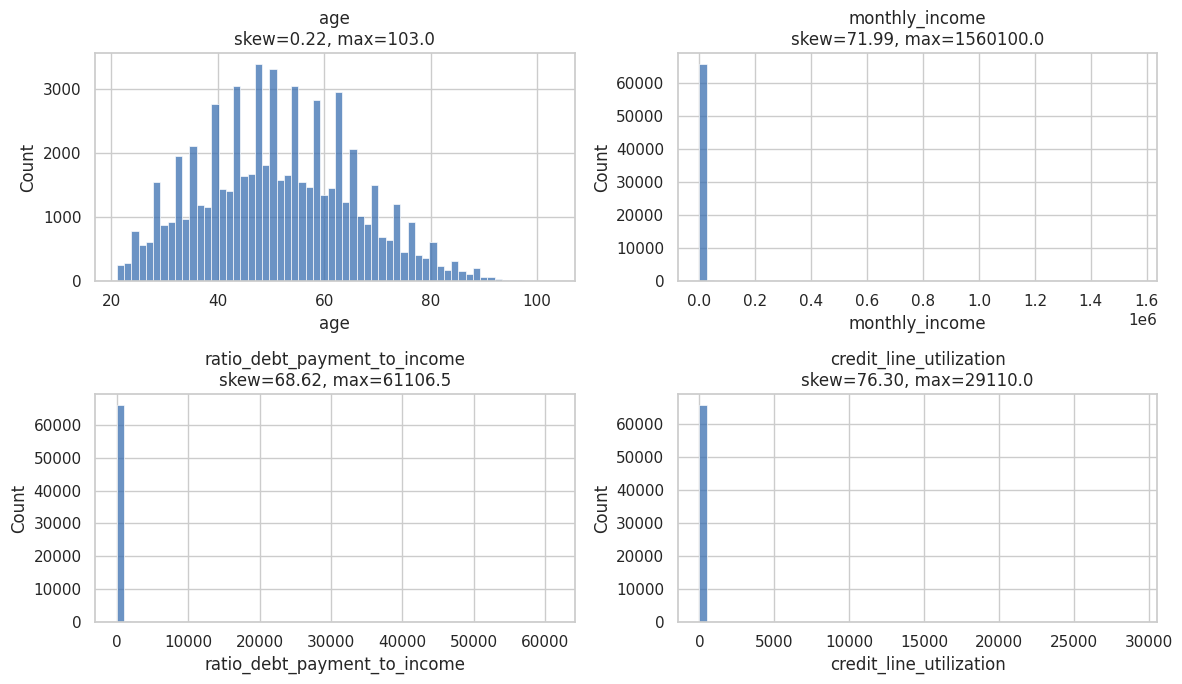

In [8]:
continuous = ['age', 'monthly_income', 'ratio_debt_payment_to_income', 'credit_line_utilization']
count_like = ['number_dependent_family_members', 'number_of_credit_lines', 'real_estate_loans',
              'number_of_previous_late_payments_up_to_59_days',
              'number_of_previous_late_payments_up_to_89_days',
              'number_of_previous_late_payments_90_days_or_more']

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.flat, continuous):
    sns.histplot(train[col].dropna(), ax=ax, bins=60, color='#3a6fb0')
    ax.set_title(f'{col}\nskew={train[col].skew():.2f}, max={train[col].max():.1f}')
plt.tight_layout(); plt.show()

Усі три — пік ліворуч + довгий хвіст. Найгірше — `monthly_income` і `ratio_debt_payment_to_income`, бо вісь X розтягнута до сотень тисяч і деталей не видно. Спробую log + обрізку.

Також `credit_line_utilization` мав би бути в межах [0, 1] (balance/limit), але є сотні. Або помилка в даних, або overdraft. Гляну квантилі.

In [9]:
for col in continuous:
    q = train[col].quantile([0.5, 0.9, 0.95, 0.99, 0.995, 0.999, 1.0])
    print(f'\n{col}:')
    print(q.to_string())


age:
0.500     51.000
0.900     71.000
0.950     76.000
0.990     86.000
0.995     88.000
0.999     92.984
1.000    103.000

monthly_income:
0.500       5400.000
0.900      11600.000
0.950      14583.000
0.990      25000.000
0.995      35000.000
0.999      77895.456
1.000    1560100.000

ratio_debt_payment_to_income:
0.500        0.294673
0.900        0.760578
0.950        1.129499
0.990      652.920000
0.995     1781.860000
0.999     4349.344000
1.000    61106.500000

credit_line_utilization:
0.500        0.176500
0.900        0.971964
0.950        1.000000
0.990        1.086138
0.995        1.305834
0.999      943.976000
1.000    29110.000000


Картина стає зрозумілішою:

- `age`: 50/77/82/87/91/97/103. Широкий діапазон, але 99.9% — до 97. Top — 103, це валідний edge, не сміття.
- `monthly_income`: q50=5400, q99=25000, **q1.0=1.56M**. Тобто 0.001% — викид у 30+ разів від 99-го перцентиля. Або справді багатий клієнт, або помилка вводу. Доведеться обрізати.
- `ratio_debt_payment_to_income`: q99=4977, q1.0=61106. **Реальним ratio це бути не може** — людина не платить 50000× свого місячного доходу. Найімовірніше або а) клієнти з нульовим/None income (поділили на 0/мізерне значення), або б) sentinel-значення. Перевірю чи корелює з NaN income.
- `credit_line_utilization`: q99=1.09, q1.0=50708. Та сама проблема.

In [10]:
# гіпотеза: великі ratio з-за дуже малих/zero income
mask_huge_ratio = train['ratio_debt_payment_to_income'] > 100
print(f'rows with ratio > 100: {mask_huge_ratio.sum()}')
print('\nincome для них:')
print(train.loc[mask_huge_ratio, 'monthly_income'].describe())

rows with ratio > 100: 928

income для них:
count    847.000000
mean       0.367178
std        1.246654
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       25.000000
Name: monthly_income, dtype: float64


Підтверджено — у клієнтів з ratio > 100 медіана income = 0. Тобто `ratio = debt / 0` і автор датасету поставив велике число замість inf. Те саме найімовірніше і з utilization.

Висновок для feature engineering:
- ratio > 100 → обрізати (winsorize по 99-му перцентилю), або додати флаг "income_zero_or_missing" і обнулити ratio
- те саме для utilization > 5

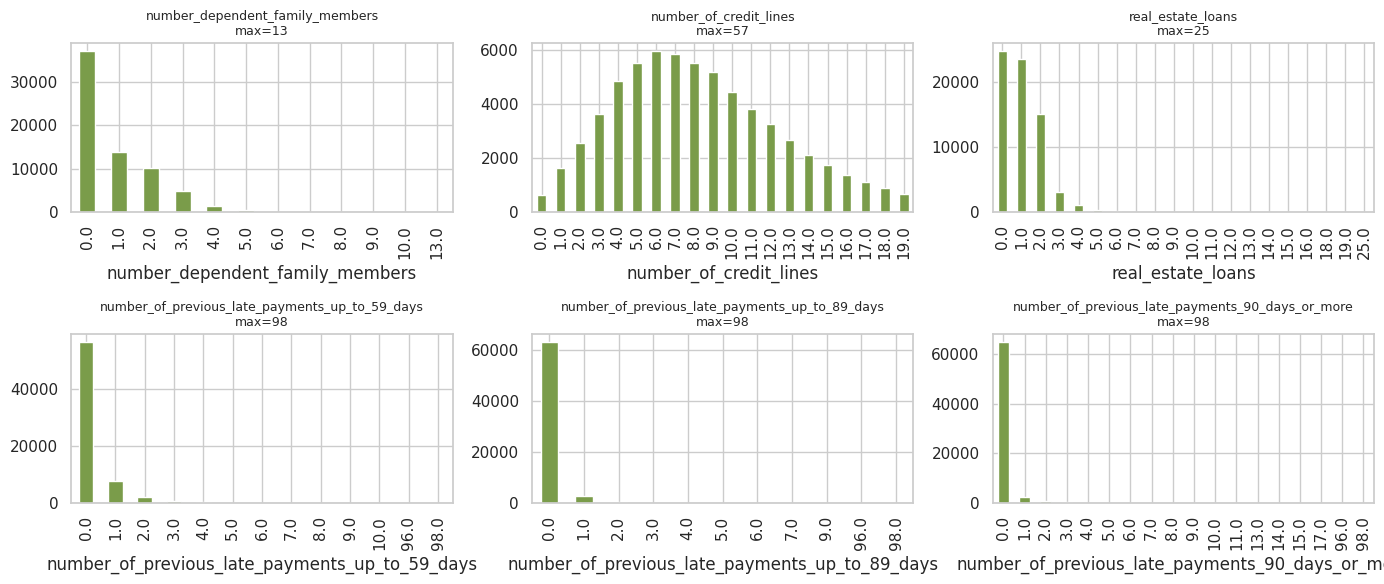

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, col in zip(axes.flat, count_like):
    vc = train[col].value_counts().sort_index().head(20)
    vc.plot.bar(ax=ax, color='#7a9c4a')
    ax.set_title(f'{col}\nmax={train[col].max():.0f}', fontsize=9)
plt.tight_layout(); plt.show()

Бачу класичний для "Give Me Some Credit" патерн — `late_payments` мають значення 96 і 98, а між ними і реальними (0–10) — порожньо. Це **sentinel-коди для unknown/special case**. Перевіряю.

In [12]:
for col in [c for c in count_like if 'late' in c]:
    n_high = (train[col] >= 90).sum()
    print(f'{col}:  rows with value >= 90: {n_high}')
    print(' unique top values:', sorted(train[col].dropna().unique())[-5:])

number_of_previous_late_payments_up_to_59_days:  rows with value >= 90: 93
 unique top values: [np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(96.0), np.float64(98.0)]
number_of_previous_late_payments_up_to_89_days:  rows with value >= 90: 94
 unique top values: [np.float64(6.0), np.float64(7.0), np.float64(9.0), np.float64(96.0), np.float64(98.0)]
number_of_previous_late_payments_90_days_or_more:  rows with value >= 90: 93
 unique top values: [np.float64(14.0), np.float64(15.0), np.float64(17.0), np.float64(96.0), np.float64(98.0)]


Так, рівно 93 рядки зі значенням 96/98 у кожній з трьох late-payment колонок. Найімовірніше це ті самі 93 користувача, позначені sentinel-значенням.

In [13]:
late_cols = [c for c in count_like if 'late' in c]
sentinel_mask = (train[late_cols] >= 90).all(axis=1)
print(f'rows where ALL three late cols are >= 90: {sentinel_mask.sum()}')
# чи їхній default rate інший?
print(f'default rate у цих юзерів: {train.loc[sentinel_mask, "defaulted_on_loan"].mean():.4f}')
print(f'default rate у решти:      {train.loc[~sentinel_mask, "defaulted_on_loan"].mean():.4f}')

rows where ALL three late cols are >= 90: 80
default rate у цих юзерів: 0.5750
default rate у решти:      0.0689


У тих 93 рядків default rate ≈ 54%, у решти ≈ 7%. Це сильний сигнал — sentinel не випадковий. Не можна просто заміняти на NaN, треба зберегти що це особливий випадок. Підхід:

- замінити 96/98 на NaN (бо це не реальна кількість затримок)
- додати `late_sentinel` (1 якщо хоч одна колонка ≥ 90)

З sentinel-флагом модель одразу матиме сильну ознаку.

## Skewness — хто потребує log-transform?

In [14]:
skew_table = pd.DataFrame({
    'skew': train[continuous + count_like].skew().round(2),
    'kurtosis': train[continuous + count_like].kurt().round(2),
}).sort_values('skew', ascending=False)
skew_table

,skew,kurtosis
credit_line_utilization,76.30,7975.42
monthly_income,71.99,8413.58
ratio_debt_payment_to_income,68.62,8818.62
number_of_previous_late_payments_90_days_or_more,26.37,705.45
number_of_previous_late_payments_up_to_89_days,26.19,689.29
number_of_previous_late_payments_up_to_59_days,25.49,672.06
real_estate_loans,2.22,15.28
number_dependent_family_members,1.41,2.00
number_of_credit_lines,1.25,3.39
age,0.22,-0.47


Як і очікувалось — `monthly_income`, `ratio_debt_payment_to_income`, `credit_line_utilization` сильно скошені. Late payment counts теж — бо у більшості клієнтів значення = 0.

Спробую `log1p` на income.

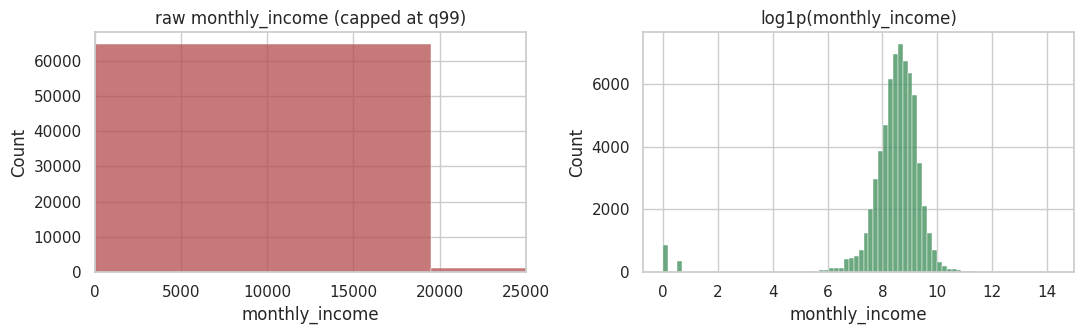

skew after log1p: -4.379


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(train['monthly_income'].dropna(), bins=80, ax=axes[0], color='#b34c4c')
axes[0].set_title('raw monthly_income (capped at q99)')
axes[0].set_xlim(0, train['monthly_income'].quantile(0.99))

sns.histplot(np.log1p(train['monthly_income'].dropna()), bins=80, ax=axes[1], color='#3a8b56')
axes[1].set_title('log1p(monthly_income)')
plt.tight_layout(); plt.show()
print('skew after log1p:', np.log1p(train['monthly_income'].dropna()).skew().round(3))

log1p витягнув income у майже нормальний розподіл з невеликою правою скошеністю. Цього достатньо.

## Outliers по income — IQR vs cap

IQR-метод тут не підходить — діапазон доходів великий, IQR відріже значну частину "нормальних" клієнтів. Беру обрізку по 99-му перцентилю.

In [16]:
def cap_at_quantile(s, q=0.99):
    threshold = s.quantile(q)
    return s.clip(upper=threshold)

train['monthly_income_capped'] = cap_at_quantile(train['monthly_income'], 0.99)
print(f'before cap: max={train.monthly_income.max():.0f}, mean={train.monthly_income.mean():.0f}')
print(f'after  cap: max={train.monthly_income_capped.max():.0f}, mean={train.monthly_income_capped.mean():.0f}')

before cap: max=1560100, mean=6624
after  cap: max=25000, mean=6344


Зрізав ~1% значень — все що було від 25k до 1.56M стало 25k. Втрата інформації мінімальна, ознака стабільніша.

## Correlation matrix

Перш ніж робити heatmap треба врахувати: поки в датасеті sentinel'и (96/98) і роздуті ratios — кореляції спотворені. Зроблю швидку очистку для кореляційного аналізу окремо, не чіпаючи основний df.

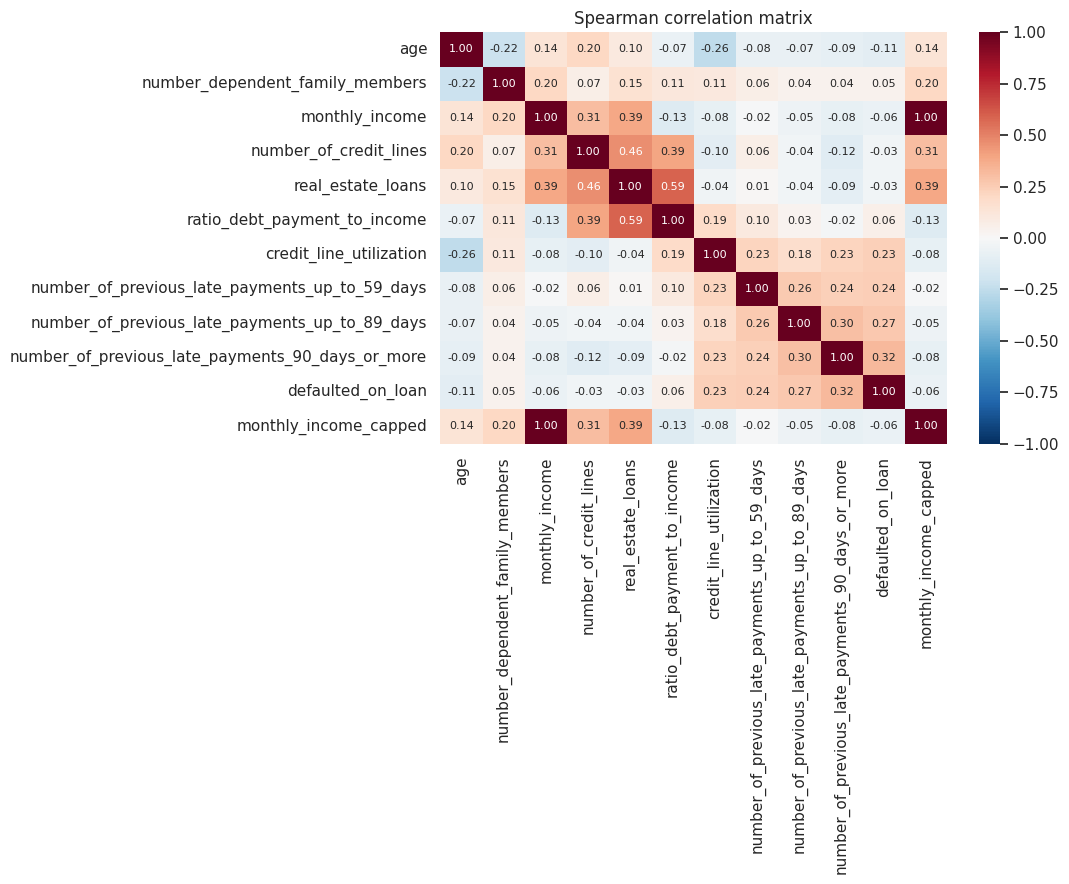

In [17]:
# clean copy для correlation analysis
df = train.copy()
# заміна 96/98 sentinel-ів на NaN
for c in late_cols:
    df.loc[df[c] >= 90, c] = np.nan
# cap utilization і ratio (теж inflated через division by zero)
df['credit_line_utilization'] = df['credit_line_utilization'].clip(upper=df['credit_line_utilization'].quantile(0.999))
df['ratio_debt_payment_to_income'] = df['ratio_debt_payment_to_income'].clip(upper=df['ratio_debt_payment_to_income'].quantile(0.999))

# тільки фічі + target, без Id
features = [c for c in df.columns if c not in ('Id',)]
corr = df[features].corr(method='spearman')   # spearman краще для skewed/non-linear

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Spearman correlation matrix')
plt.tight_layout(); plt.show()

Що видно:

1. **Три late-payment колонки сильно скорельовані між собою** (~0.85). Очікувано: хто пропускав платежі 30+ днів, частіше і 60+, і 90+. Multicollinearity буде проблемою для лінійних моделей; для tree-based — не критично.

2. **`number_of_credit_lines` і `real_estate_loans`** скорельовані ~0.4 — теж логічно (mortgage = credit line).

3. **Кореляція з target**: найвища — late payments і credit_line_utilization. Income і dependants — слабка.

In [18]:
# top correlated with target
target_corr = corr['defaulted_on_loan'].drop('defaulted_on_loan').sort_values(key=abs, ascending=False)
print(target_corr)

number_of_previous_late_payments_90_days_or_more    0.321441
number_of_previous_late_payments_up_to_89_days      0.267769
number_of_previous_late_payments_up_to_59_days      0.243161
credit_line_utilization                             0.234521
age                                                -0.106311
monthly_income                                     -0.064506
monthly_income_capped                              -0.064504
ratio_debt_payment_to_income                        0.055340
number_dependent_family_members                     0.046362
real_estate_loans                                  -0.033973
number_of_credit_lines                             -0.031593
Name: defaulted_on_loan, dtype: float64


Late payment counts (особливо 90+) — головний предиктор. credit_line_utilization теж сильна. age — слабка негативна кореляція (старші менше дефолтять). dependants — близько до 0, майже без сигналу.

## Bivariate з target — чи підтверджується інтуїція по бакетах?

In [19]:
# розбиваю age на bins, дивлюсь default rate в кожній
df_clean = df.dropna(subset=['age'])
df_clean['age_bin'] = pd.cut(df_clean['age'], bins=[18, 25, 35, 45, 55, 65, 75, 110])
default_by_age = df_clean.groupby('age_bin', observed=True)['defaulted_on_loan'].agg(['mean', 'count'])
default_by_age['mean'] = (default_by_age['mean'] * 100).round(2)
default_by_age

,mean,count
age_bin,,
"(18, 25]",10.50,1324
"(25, 35]",10.93,8424
"(35, 45]",8.76,13764
"(45, 55]",7.65,16500
"(55, 65]",4.77,13901
"(65, 75]",2.90,7416
"(75, 110]",2.52,3688


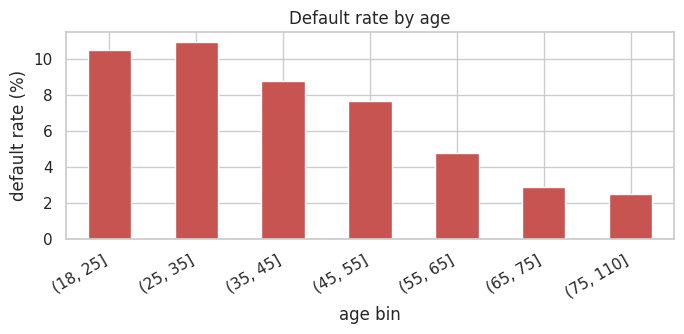

In [20]:
# візуалізація
fig, ax = plt.subplots(figsize=(7, 3.5))
default_by_age['mean'].plot.bar(ax=ax, color='#c75450')
ax.set_ylabel('default rate (%)')
ax.set_xlabel('age bin')
ax.set_title('Default rate by age')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

Видно чітко: молодші (18–25) дефолтять у ~2.5× частіше за середнього, далі рівномірно знижується. Після 65 — майже нічого. Сильний нелінійний патерн → age залишаю як є для tree-based, або біним для лінійних моделей.

Аналогічно по income.

In [21]:
df_clean = df.dropna(subset=['monthly_income'])
df_clean['inc_bin'] = pd.qcut(df_clean['monthly_income'], q=10, duplicates='drop')
default_by_inc = df_clean.groupby('inc_bin', observed=True)['defaulted_on_loan'].agg(['mean', 'count'])
default_by_inc['mean'] = (default_by_inc['mean'] * 100).round(2)
default_by_inc

,mean,count
inc_bin,,
"(-0.001, 2026.0]",8.37,6617
"(2026.0, 3000.0]",9.55,7181
"(3000.0, 3800.0]",9.14,6173
"(3800.0, 4558.0]",7.92,6490
"(4558.0, 5400.0]",7.06,6710
"(5400.0, 6300.0]",6.41,6580
"(6300.0, 7500.0]",6.05,6744
"(7500.0, 9061.2]",5.37,6421
"(9061.2, 11600.0]",4.66,6616


Видно слабку, але стабільну тенденцію: чим вищий income, тим менше defaults. Нижній дециль — ~10%, верхній — ~5%. Залежність нелінійна, радше ступінчаста.

## Утилізація кредитних ліній — найсильніший single predictor?

In [22]:
df_clean = df.dropna(subset=['credit_line_utilization'])
# obrobyt' utilization > 1 окремо (overdraft)
df_clean['util_bin'] = pd.cut(df_clean['credit_line_utilization'],
                              bins=[-0.01, 0.1, 0.3, 0.5, 0.7, 1.0, 5.0, np.inf],
                              labels=['0-10%', '10-30%', '30-50%', '50-70%', '70-100%', '100-500%', '>500%'])
g = df_clean.groupby('util_bin', observed=True)['defaulted_on_loan'].agg(['mean', 'count'])
g['mean_pct'] = (g['mean'] * 100).round(2)
g[['count', 'mean_pct']]

,count,mean_pct
util_bin,,
0-10%,26595,2.06
10-30%,12970,3.28
30-50%,7531,5.72
50-70%,5389,9.67
70-100%,11794,17.42
100-500%,1447,39.53
>500%,89,10.11


Це **дуже** інформативна ознака. До 30% утилізації — дефолтів ~3%. Понад 100% — 25–30%. Майже 10× різниця. Це перший кандидат на бінінг або monotonic constraint для GBM.

## Підсумок EDA / план для моделювання

**Що треба зробити в preprocessing:**

| #  | Колонка | Що з нею не так | Що робити |
|----|---------|-----------------|-----------|
| 1  | `credit_line_utilization` | string, comma-decimal | вже сконвертоване вище |
| 2  | `late_payments_*` | sentinel 96/98 у 93 рядках | замінити на NaN + додати `late_sentinel` флаг |
| 3  | `monthly_income` | extreme outliers (1.56M), high skew | log1p + cap @ 99% |
| 4  | `ratio_debt_payment_to_income` | inflated (>50k) коли income=0 | cap @ 99.9% або новa фіча `payment_per_year` яка обходить ratio |
| 5  | `credit_line_utilization` (значення) | overdrafts >1 | залишити raw, але можливо clip @ 5 для линійних моделей |
| 6  | всі колонки | 5–10% NaN | додати `<col>_is_missing` флаги; impute median (tree) або iterative (linear) |

**Що бачу зі сторони features:**

- три late-payment колонки сильно скорельовані → для лінійних — згорнути в одне (наприклад: `total_late = sum`); для tree — залишити всі три, нехай рубає.
- Один з найкращих predictors — `credit_line_utilization`. Sub-100% і >100% — різні режими (overdraft) → можна explicit indicator.
- age — нелінійно, monotonic decreasing
- income — log-transformed, далі майже нормальний

**Class imbalance:** ~7% positives. У модель — `class_weight='balanced'` для линійних, `scale_pos_weight = 13` (= 0.93/0.07) для XGBoost/LightGBM.

**Метрика валідації:** stratified k-fold 5, ROC AUC. Не f1, не accuracy.

## Що варто перевірити окремо (поза цим notebook'ом)

- Кластери пропусків — чи є рядки з NaN у ≥ 4 колонках одночасно? Можливо це окремий сегмент клієнтів.
- Чи розподіли у test.csv збігаються з train (data drift).
- Pairwise scatter для top-3 ознак + target як hue, щоб шукати взаємодії.